### INAE demografico de albacete

In [19]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path("..")
ine_path = BASE_DIR / "data" / "raw" / "poblacion_ine_2855.xlsx"
gym_path = BASE_DIR / "data" / "processed" / "gym_market_opportunity_albacete.csv"

print("INE existe?", ine_path.exists(), "|", ine_path)
print("GYM existe?", gym_path.exists(), "|", gym_path)

# --- cargar GYM (ok) ---
gym = pd.read_csv(gym_path)

# --- cargar INE de forma robusta (evita 'Unnamed') ---
raw = pd.read_excel(ine_path, header=None)

# buscamos la fila del header real: donde aparecen varios años (1996, 2000, 2015, 2025...)
header_row = None
for i in range(0, 25):
    row = raw.iloc[i].astype(str)
    n_years = row.str.fullmatch(r"(19|20)\d{2}", na=False).sum()
    if n_years >= 5:
        header_row = i
        break

if header_row is None:
    raise ValueError("No pude detectar la fila del header (años). Mirá raw.head(20) para ver dónde están los años.")

print("Header INE detectado en fila:", header_row)

ine = pd.read_excel(ine_path, header=header_row)
ine = ine.loc[:, ~ine.columns.astype(str).str.contains("^Unnamed")].copy()

# primera columna = municipio (en estos excels suele ser así)
ine = ine.rename(columns={ine.columns[0]: "municipio"})
ine.columns = [str(c).strip() for c in ine.columns]  # años como string: "2015", "2020", "2025"

ine.head()

INE existe? True | ..\data\raw\poblacion_ine_2855.xlsx
GYM existe? True | ..\data\processed\gym_market_opportunity_albacete.csv
Header INE detectado en fila: 7


c:\Users\juanc\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\juanc\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,municipio,2025,2024,2023,2022,2021,2020,2019,2018,2017,...,2005.2,2004.2,2003.2,2002.2,2001.2,2000.2,1999.2,1998.2,1997.2,1996.2
0,02001 Abengibre,753.0,759.0,760.0,739.0,748.0,761.0,790.0,757.0,748.0,...,494.0,494.0,479.0,494.0,500.0,497,503,508,,513
1,02002 Alatoz,504.0,497.0,491.0,496.0,496.0,506.0,519.0,529.0,555.0,...,280.0,288.0,297.0,299.0,311.0,316,328,324,,326
2,02003 Albacete,175400.0,174137.0,173206.0,172357.0,172722.0,174336.0,173329.0,173050.0,172816.0,...,81102.0,79605.0,78891.0,77426.0,76229.0,76383,75388,74328,,73565
3,02 Albacete,390406.0,388599.0,387174.0,385727.0,386464.0,388270.0,388167.0,388786.0,390032.0,...,192016.0,189705.0,188417.0,186329.0,184457.0,182952,181811,180539,,180880
4,02004 Albatana,644.0,663.0,655.0,670.0,681.0,679.0,692.0,693.0,698.0,...,439.0,439.0,437.0,436.0,441.0,437,430,432,,449


In [20]:
import re

# 1) quitar fila provincia (total)
ine = ine[ine["municipio"] != "02 Albacete"].copy()

# 2) quedarnos con columnas de años "limpios" (sin .2) + municipio
cols_keep = ["municipio"]
for c in ine.columns:
    c_str = str(c)
    # aceptar solo años tipo "1996"..."2025" (sin ".2")
    if re.fullmatch(r"(19|20)\d{2}", c_str):
        cols_keep.append(c)

ine = ine[cols_keep].copy()

# 3) limpiar municipio: quitar "02001 " y dejar "Abengibre"
ine["municipio"] = ine["municipio"].astype(str).str.replace(r"^\d{5}\s+", "", regex=True).str.strip()

# 4) convertir años a numérico (por si hay strings vacíos)
for y in cols_keep[1:]:
    ine[y] = pd.to_numeric(ine[y], errors="coerce")

ine.head()

,municipio,2025,2024,2023,2022,2021,2020,2019,2018,2017,...,2005,2004,2003,2002,2001,2000,1999,1998,1997,1996
0,Abengibre,753.0,759.0,760.0,739.0,748.0,761.0,790.0,757.0,748.0,...,977.0,977.0,959.0,972.0,987.0,976.0,996.0,1007.0,NaN,1019.0
1,Alatoz,504.0,497.0,491.0,496.0,496.0,506.0,519.0,529.0,555.0,...,603.0,603.0,625.0,633.0,648.0,661.0,684.0,675.0,NaN,683.0
2,Albacete,175400.0,174137.0,173206.0,172357.0,172722.0,174336.0,173329.0,173050.0,172816.0,...,159518.0,156466.0,155142.0,152155.0,149507.0,149667.0,147527.0,145454.0,NaN,143799.0
4,Albatana,644.0,663.0,655.0,670.0,681.0,679.0,692.0,693.0,698.0,...,856.0,854.0,852.0,859.0,875.0,872.0,870.0,874.0,NaN,907.0
5,Alborea,672.0,676.0,666.0,663.0,670.0,664.0,658.0,650.0,697.0,...,827.0,793.0,792.0,801.0,808.0,814.0,813.0,809.0,NaN,798.0


In [21]:
print("Tiene fila provincia?", (ine["municipio"] == "02 Albacete").any())
print("Años clave presentes:", [y for y in ["2015","2020","2025"] if y in ine.columns])

Tiene fila provincia? False
Años clave presentes: ['2015', '2020', '2025']


In [22]:
# Calcular crecimiento demografico
ine["growth_5y"] = (ine["2025"] - ine["2020"]) / ine["2020"]

ine["growth_10y"] = (ine["2025"] - ine["2015"]) / ine["2015"]

ine_growth = ine[["municipio", "growth_5y", "growth_10y"]]


In [23]:
# Unir con mi dataset de oportunidades
df_final = gym.merge(
    ine_growth,
    on="municipio",
    how="left"
)

df_final.head()

,municipio,poblacion_2025,gyms_google,fitness_x10k,lat,lon,radius_m,gyms_sample_names,gyms_google_new,fitness_x10k_new,catchment_pop_25km,real_market_potential,dist_albacete_km,opportunity_score,catchment_gyms_25km,opportunity_score_v2,growth_5y,growth_10y
0,Abengibre,753,37,491.367862,39.210505,-1.541444,4000,NaN,0.0,0.000000,27838,27838.000000,36.521899,27838.000000,23.0,1159.916667,-0.010512,-0.037084
1,Alatoz,504,28,555.555556,39.095050,-1.361995,4000,NaN,0.0,0.000000,16360,16360.000000,44.454498,16360.000000,13.0,1168.571429,-0.003953,-0.173770
2,Albacete,175400,53,3.021665,38.994398,-1.860173,18000,"967GYM; ALMA SERENA ( CENTRO DE YOGA, MEDITACI...",78.0,4.446978,188399,2384.797468,0.000000,715.439241,89.0,2093.322222,0.006103,0.019051
3,Albatana,644,46,714.285714,38.572000,-1.520560,4000,Circuito ALBATANA,1.0,15.527950,43803,21901.500000,55.430927,21901.500000,24.0,1752.120000,-0.051546,-0.134409
4,Alborea,672,20,297.619048,39.279205,-1.395773,4000,Polideportivo Municipal de Alborea,1.0,14.880952,18660,9330.000000,51.060574,9330.000000,17.0,1036.666667,0.012048,-0.108753


In [24]:
# Crear score de crecimiento
df_final["growth_score"] = (
    df_final["growth_5y"] * 0.6 +
    df_final["growth_10y"] * 0.4
)

In [25]:
# score final de invercion
df_final["investment_score"] = (
    df_final["opportunity_score_v2"] * 0.7 +
    df_final["growth_score"] * 100 * 0.3
)

In [26]:
# Ranking final
ranking = df_final.sort_values(
    "investment_score",
    ascending=False
)

ranking[
    [
        "municipio",
        "poblacion_2025",
        "gyms_google_new",
        "opportunity_score_v2",
        "growth_5y",
        "investment_score"
    ]
].head(15)

,municipio,poblacion_2025,gyms_google_new,opportunity_score_v2,growth_5y,investment_score
2,Albacete,175400,78.0,2093.322222,0.006103,1465.664019
26,Chinchilla de Monte-Aragón,4614,5.0,2029.838710,0.097265,1423.918752
61,Pozo Cañada,2704,1.0,2034.385417,-0.031172,1423.051926
37,"Herrera, La",308,1.0,1955.961165,-0.043478,1367.041504
51,Motilleja,673,0.0,1932.941748,0.164360,1358.569052
75,Valdeganga,1970,2.0,1874.846847,-0.010050,1312.085319
34,"Gineta, La",2656,2.0,1800.025862,0.042386,1261.368733
49,Montalvos,74,0.0,1800.025862,-0.159091,1253.376689
3,Albatana,644,1.0,1752.120000,-0.051546,1223.943262
74,Tobarra,8006,5.0,1728.925926,0.038526,1210.991291


In [27]:
# guardamos ds!
df_final.to_csv(
    "gym_market_opportunity_albacete_growth.csv",
    index=False
)

In [28]:
# calcular crecimiento (1 celda)
import numpy as np

ine["growth_5y"]  = (ine["2025"] - ine["2020"]) / ine["2020"].replace(0, np.nan)
ine["growth_10y"] = (ine["2025"] - ine["2015"]) / ine["2015"].replace(0, np.nan)

ine_growth = ine[["municipio", "growth_5y", "growth_10y"]].copy()

ine_growth.sort_values("growth_5y", ascending=False).head(10)

,municipio,growth_5y,growth_10y
52,Motilleja,0.164360,0.212613
47,Masegoso,0.125000,-0.033058
27,Chinchilla de Monte-Aragón,0.097265,0.106740
46,Mahora,0.075624,0.030239
59,Peñas de San Pedro,0.067432,0.039832
21,Casas de Juan Núñez,0.062594,0.019537
79,Villalgordo del Júcar,0.051724,0.010462
83,Villatoya,0.045872,-0.008696
25,Caudete,0.043378,0.027157
35,"Gineta, La",0.042386,0.048973


In [29]:
# unir con tu dataset de oportunidades
import unicodedata
from pathlib import Path

BASE_DIR = Path("..")
gym = pd.read_csv(BASE_DIR / "data" / "processed" / "gym_market_opportunity_albacete.csv")

def norm(s):
    s = str(s).strip().lower()
    s = "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")
    return s

gym["mun_key"] = gym["municipio"].apply(norm)
ine_growth["mun_key"] = ine_growth["municipio"].apply(norm)

df_final = gym.merge(
    ine_growth.drop(columns=["municipio"]),
    on="mun_key",
    how="left"
).drop(columns=["mun_key"])

print("Growth faltante:", df_final["growth_5y"].isna().sum(), "de", len(df_final))
df_final[["municipio", "growth_5y", "growth_10y"]].head()

Growth faltante: 0 de 87


,municipio,growth_5y,growth_10y
0,Abengibre,-0.010512,-0.037084
1,Alatoz,-0.003953,-0.173770
2,Albacete,0.006103,0.019051
3,Albatana,-0.051546,-0.134409
4,Alborea,0.012048,-0.108753


In [30]:
# guardar dataset
out_path = BASE_DIR / "data" / "processed" / "gym_market_opportunity_albacete_growth.csv"
df_final.to_csv(out_path, index=False)
print("Guardado:", out_path)

Guardado: ..\data\processed\gym_market_opportunity_albacete_growth.csv


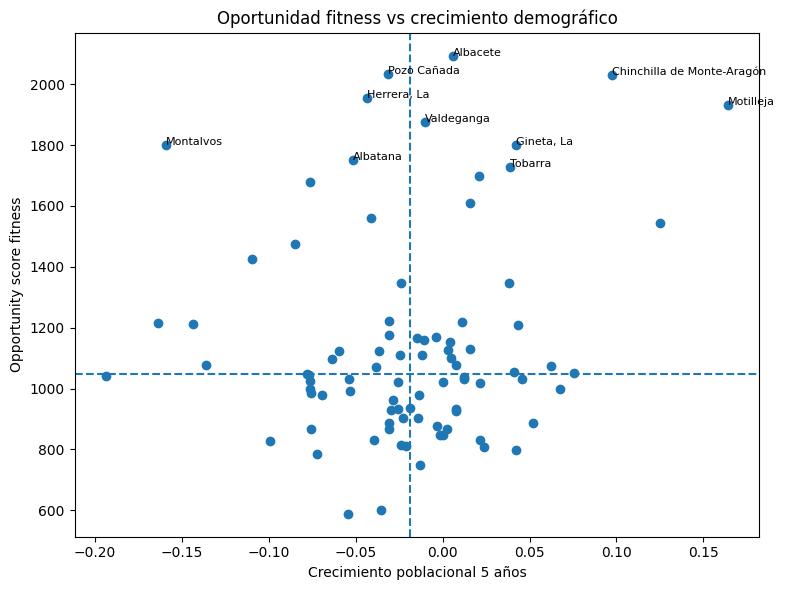

In [31]:
# grafico de oportunidades
import matplotlib.pyplot as plt
import numpy as np

x = df_final["growth_5y"]
y = df_final["opportunity_score_v2"]

x_med = np.nanmedian(x)
y_med = np.nanmedian(y)

plt.figure(figsize=(8,6))

plt.scatter(x, y)

plt.axvline(x_med, linestyle="--")
plt.axhline(y_med, linestyle="--")

plt.xlabel("Crecimiento poblacional 5 años")
plt.ylabel("Opportunity score fitness")

plt.title("Oportunidad fitness vs crecimiento demográfico")

top = df_final.sort_values("opportunity_score_v2", ascending=False).head(10)

for _, r in top.iterrows():
    plt.text(r["growth_5y"], r["opportunity_score_v2"], r["municipio"], fontsize=8)

plt.tight_layout()

plt.savefig("../reports/figures/fitness_opportunity_vs_growth.png", dpi=200)

plt.show()

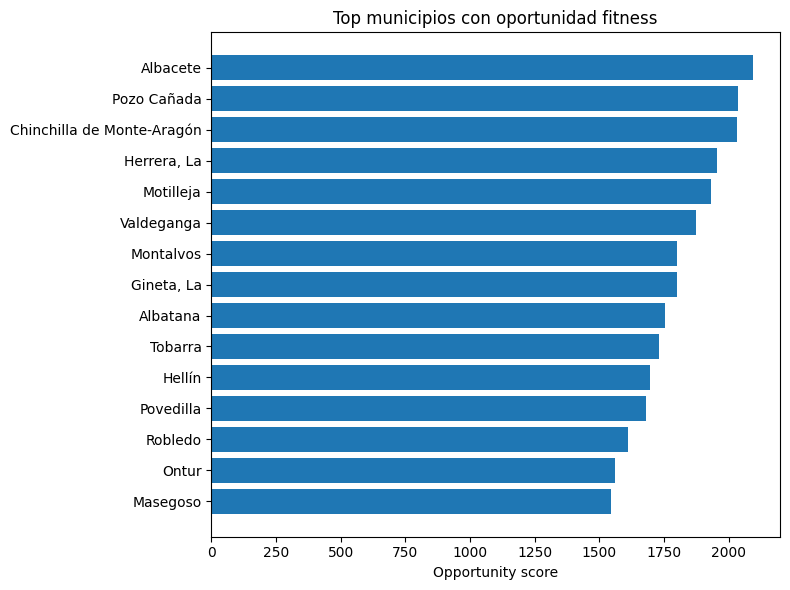

In [32]:
# grafico top
top15 = df_final.sort_values("opportunity_score_v2", ascending=False).head(15)

top15 = top15.sort_values("opportunity_score_v2")

plt.figure(figsize=(8,6))

plt.barh(top15["municipio"], top15["opportunity_score_v2"])

plt.xlabel("Opportunity score")
plt.title("Top municipios con oportunidad fitness")

plt.tight_layout()

plt.savefig("../reports/figures/top_fitness_opportunities.png", dpi=200)

plt.show()

In [33]:
# Celda para crear la clasificación
x_med = df_final["growth_5y"].median()
y_med = df_final["opportunity_score_v2"].median()

def classify_market(row):
    growth_high = row["growth_5y"] >= x_med
    opp_high = row["opportunity_score_v2"] >= y_med

    if growth_high and opp_high:
        return "Mercado emergente"
    elif growth_high and not opp_high:
        return "Mercado competitivo"
    elif not growth_high and opp_high:
        return "Oportunidad latente"
    else:
        return "Mercado débil"

df_final["market_type"] = df_final.apply(classify_market, axis=1)

df_final[["municipio", "growth_5y", "opportunity_score_v2", "market_type"]].head(10)

,municipio,growth_5y,opportunity_score_v2,market_type
0,Abengibre,-0.010512,1159.916667,Mercado emergente
1,Alatoz,-0.003953,1168.571429,Mercado emergente
2,Albacete,0.006103,2093.322222,Mercado emergente
3,Albatana,-0.051546,1752.120000,Oportunidad latente
4,Alborea,0.012048,1036.666667,Mercado competitivo
5,Alcadozo,-0.018547,936.333333,Mercado competitivo
6,Alcalá del Júcar,-0.053601,1031.500000,Mercado débil
7,Alcaraz,-0.030967,1221.666667,Oportunidad latente
8,Almansa,0.004243,1152.371429,Mercado emergente
9,Alpera,0.007519,1077.233333,Mercado emergente


In [34]:
# Ver cuántos municipios hay en cada tipo
df_final["market_type"].value_counts()

market_type
Mercado emergente      24
Mercado débil          23
Oportunidad latente    20
Mercado competitivo    20
Name: count, dtype: int64

In [35]:
# Ver cuáles son los mejores “mercados emergentes”
df_final[df_final["market_type"] == "Mercado emergente"][
    ["municipio", "poblacion_2025", "growth_5y", "opportunity_score_v2"]
].sort_values("opportunity_score_v2", ascending=False).head(15)

,municipio,poblacion_2025,growth_5y,opportunity_score_v2
2,Albacete,175400,0.006103,2093.322222
26,Chinchilla de Monte-Aragón,4614,0.097265,2029.838710
51,Motilleja,673,0.164360,1932.941748
75,Valdeganga,1970,-0.010050,1874.846847
34,"Gineta, La",2656,0.042386,1800.025862
74,Tobarra,8006,0.038526,1728.925926
36,Hellín,30836,0.021060,1697.320000
68,Robledo,382,0.015957,1609.166667
46,Masegoso,117,0.125000,1544.500000
12,"Ballestero, El",411,0.037879,1345.500000


In [36]:
# crear una versión “viable”
df_viable = df_final[df_final["poblacion_2025"] > 2000].copy()

df_viable[df_viable["market_type"] == "Mercado emergente"][
    ["municipio", "poblacion_2025", "growth_5y", "opportunity_score_v2"]
].sort_values("opportunity_score_v2", ascending=False).head(15)

,municipio,poblacion_2025,growth_5y,opportunity_score_v2
2,Albacete,175400,0.006103,2093.322222
26,Chinchilla de Monte-Aragón,4614,0.097265,2029.838710
34,"Gineta, La",2656,0.042386,1800.025862
74,Tobarra,8006,0.038526,1728.925926
36,Hellín,30836,0.021060,1697.320000
81,Villarrobledo,25400,0.011308,1217.318182
24,Caudete,10439,0.043378,1208.758621
8,Almansa,24615,0.004243,1152.371429
23,Casas-Ibáñez,4616,0.015845,1130.800000
79,Villamalea,4083,0.003194,1127.684211


In [37]:
out_path = BASE_DIR / "data" / "processed" / "gym_market_opportunity_albacete_growth.csv"
df_final.to_csv(out_path, index=False)
print("Dataset actualizado guardado en:", out_path)
print(df_final.columns)

Dataset actualizado guardado en: ..\data\processed\gym_market_opportunity_albacete_growth.csv
Index(['municipio', 'poblacion_2025', 'gyms_google', 'fitness_x10k', 'lat',
       'lon', 'radius_m', 'gyms_sample_names', 'gyms_google_new',
       'fitness_x10k_new', 'catchment_pop_25km', 'real_market_potential',
       'dist_albacete_km', 'opportunity_score', 'catchment_gyms_25km',
       'opportunity_score_v2', 'growth_5y', 'growth_10y', 'market_type'],
      dtype='object')


### Objetivo: analizar el crecimiento poblacional y detectar mercados emergentes.

Contenido:

carga de población histórica (INE)

cálculo de:

growth_5y

growth_10y

integración con dataset de oportunidades

gráfico oportunidad vs crecimiento

clasificación de municipios en:

Mercado emergente
Mercado competitivo
Oportunidad latente
Mercado débil

Resultado:

dataset final con market_type

gráficos analíticos